In [ ]:
import numpy as np
import csv
import matplotlib.pyplot as plt
refractive_index_path = "./Querry-o.csv"
import scipy

In [ ]:
import sympy as sp
#for computing derivatives

In [ ]:
with open(refractive_index_path) as csvfile:
  reader = csv.reader(csvfile)
  refractive_index_array = []
  for row in reader:
    refractive_index_array.append(row)
  refractive_index_array.remove(refractive_index_array[613]) #remove the blank space row
  refractive_index_array = np.array(refractive_index_array) #convert from list to nparray
n_array = refractive_index_array[1:613].astype(np.float128) #chop out the headers
k_array = refractive_index_array[614:1226].astype(np.float128)

In [ ]:
# in microns per second, c is 2.98 * 10**14
c = 2.98 * 10**14

#Convert k and n arrays to be with respect to omega

k_array_omega = np.flip(np.concatenate((2*np.pi*c/(k_array[:, 0]).reshape((-1, 1)), k_array[:, 1].reshape(-1,1)), axis=1), axis=0)
n_array_omega = np.flip(np.concatenate((2*np.pi*c/(n_array[:, 0]).reshape((-1, 1)), n_array[:, 1].reshape(-1,1)), axis=1), axis=0)

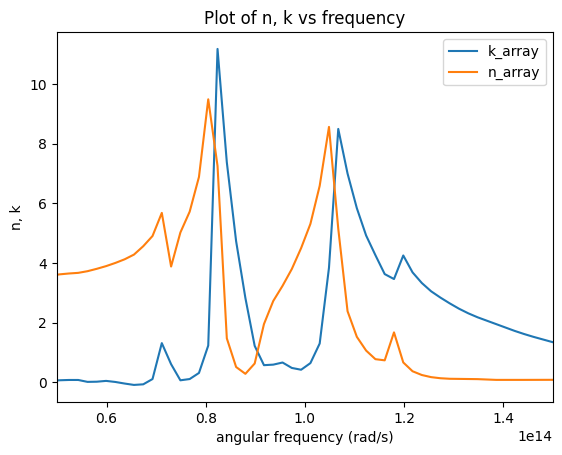

In [ ]:
#Plot of k_array vs frequency
plt.plot(k_array_omega[:, 0], k_array_omega[:,1], label="k_array")
plt.plot(n_array_omega[:, 0], n_array_omega[:,1], label="n_array")
plt.xlabel("angular frequency (rad/s)")
plt.xlim((5e13,1.5e14))
plt.ylabel("n, k")
plt.legend()
plt.title("Plot of n, k vs frequency")
plt.show()

In [ ]:
### Turn our n, j back into a single complex variable
complex_n_omega = n_array_omega[:,1] + k_array_omega[:,1]*1j
omega_values = n_array_omega[:,0]

susceptibility = complex_n_omega**2 - 1

Source: Saleh and Teich p 176. The Lorentz oscillator model essentially posits that the response of a material can be modeled as a driven harmonic oscillator. That is, since the polarization vector $\vec{P}$ characterizes such a response, we have
$$\frac{d^2P}{dt^2} + 2 \gamma \frac{dP}{dt} + \omega_0^2 P = \epsilon_0 \chi_0 \omega_0^2 E$$
This is clearly a simple harmonic oscillator.

As a remark, comparing with the classical simple harmonic oscillator $\frac{d^2x}{dt^2} + 2 \gamma \frac{dx}{dt} + \omega_0^2 x = \frac{F}{m}$ and substituting $p = -ex$ (so $P = -Nex$) and $F = -qe$ gives the classical model of susceptibility,
$$\chi_0 = \frac{Ne^2}{\epsilon_0m \omega_0^2}.$$

We then claim that $P$ has a frequency-dependent response to $E$, that is $P = \epsilon_0 \chi(\omega) E$, which I think is a pretty reasonable claim. Solving for $\chi$ gives
$$\chi(\omega) = \chi_0 \frac{\omega_0^2}{\omega_0^2 - \omega^2 - 2 \gamma i \omega}$$
The multi-lorentzian model just posits that there are more resonance modes. Based on the fact that there are 4 spikes in the plot, I think we should use 4 oscillators. This is because each spike corresponds to the resonance frequency of one of the oscilators.

In [ ]:
def oscillator_i(omega, f_i, gamma_i, omega_i):
  return f_i*omega_i**2/(omega_i**2 - omega**2 - (2*gamma_i*omega*1j))

def oscillator_function(omega, params):
  oscillator_sum = 0
  for i in range(0,len(params),3):
    oscillator_sum += oscillator_i(omega, params[i], params[i+1], params[i+2])
  return oscillator_sum

def residuals(params, x, y):
  difference = y - oscillator_function(x, params)
  return np.concatenate((np.real(difference), np.imag(difference)))


##Going to eyeball some values for these to roughly fit to the spikes. Format is:
#guess_i = [f, gamma, omega]
spike_1 = [5.8, 5e13, 0.7e14]
spike_2 = [8.8, 5e13, 0.8e14]
spike_3 = [9.2, 5e13, 1.01e14]
spike_4 = [1.8, 5e13, 1.2e14]
x_0 = np.concatenate((spike_1, spike_2, spike_3, spike_4))

optimized_things = scipy.optimize.least_squares(residuals, x_0, args=(omega_values, susceptibility))

In [ ]:
# plt.plot(omega_values, np.real(susceptibility), label="Re(chi)")
# plt.plot(omega_values, np.imag(susceptibility), label="Im(chi)")
# plt.xlim((5e13,1.5e14))
# plt.ylabel("chi, real and imaginary")
# plt.legend()
# plt.title("susceptibility plots")
# plt.show()

In [ ]:
# print("The x positions of the spikes are", optimized_things.x.reshape(-1, 3)[:,2])
# print("The initial x positions of the spikes were", x_0.reshape(-1, 3)[:,2])

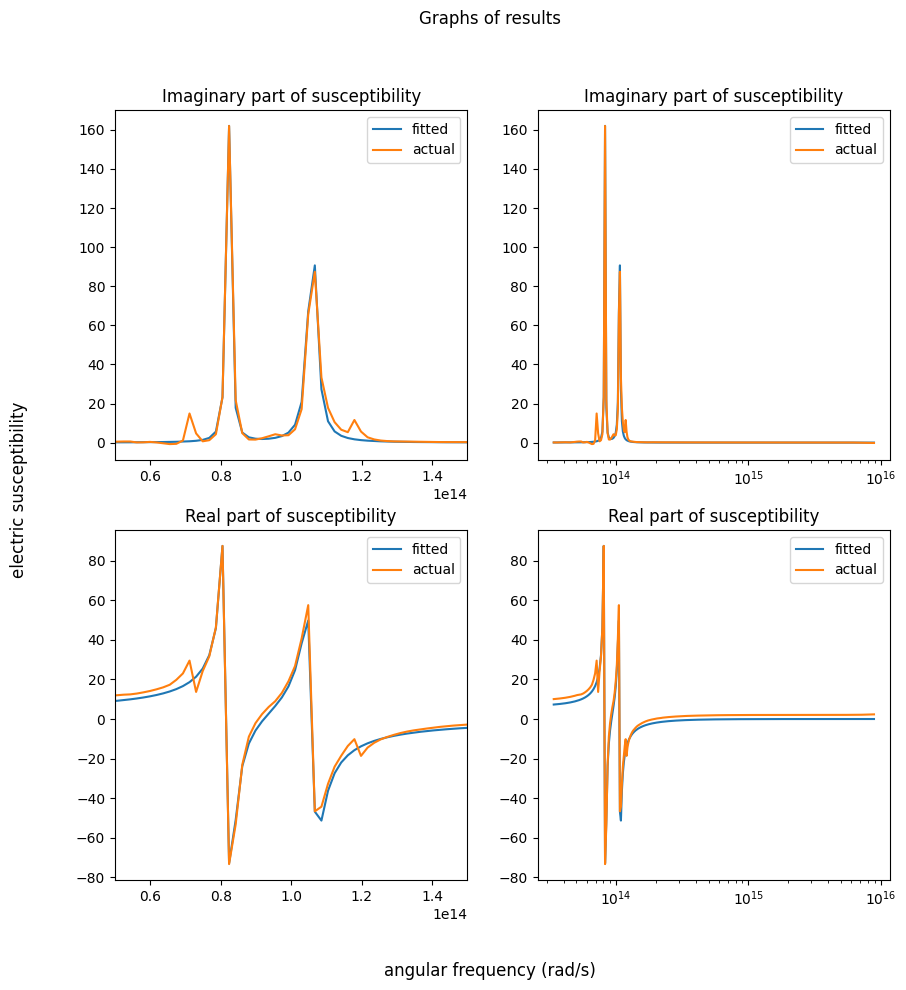

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

fig.supxlabel("angular frequency (rad/s)")
fig.supylabel("electric susceptibility")

ax[0,0].plot(omega_values, np.imag(oscillator_function(omega_values, optimized_things.x)), label="fitted")
ax[0,0].plot(omega_values, np.imag(susceptibility), label="actual")
ax[0,0].set_xlim((5e13,1.5e14))
ax[0,0].set_title("Imaginary part of susceptibility")
ax[0,0].legend()

ax[1,0].plot(omega_values, np.real(oscillator_function(omega_values, optimized_things.x)), label="fitted")
ax[1,0].plot(omega_values, np.real(susceptibility), label="actual")
ax[1,0].set_xlim((5e13,1.5e14))
ax[1,0].set_title("Real part of susceptibility")
ax[1,0].legend()

ax[0,1].semilogx(omega_values, np.imag(oscillator_function(omega_values, optimized_things.x)), label="fitted")
ax[0,1].semilogx(omega_values, np.imag(susceptibility), label="actual")
ax[0,1].set_title("Imaginary part of susceptibility")
ax[0,1].legend()

ax[1,1].semilogx(omega_values, np.real(oscillator_function(omega_values, optimized_things.x)), label="fitted")
ax[1,1].semilogx(omega_values, np.real(susceptibility), label="actual")
ax[1,1].set_title("Real part of susceptibility")
ax[1,1].legend()

fig.suptitle("Graphs of results")
fig.show()

In [ ]:
print("The resonance frequencies of the oscillators are", optimized_things.x.reshape(-1, 3)[:,2], "rad/s.")
print("The damping rates of the oscillators are", optimized_things.x.reshape(-1, 3)[:,1], "rad/s.")
print("The oscillator strengths are", optimized_things.x.reshape(-1, 3)[:,0], ".")

The resonance frequencies of the oscillators are [8.15855361e+13 8.15845492e+13 1.06044906e+14 8.15934510e+13] rad/s.
The damping rates of the oscillators are [1.16905716e+12 1.16773764e+12 1.46211234e+12 1.18008608e+12] rad/s.
The oscillator strengths are [ 1.00021281e+05 -8.91401190e+04  3.05526586e+00 -1.08779013e+04] .


Ultimately, it seems that our model fits decently well. The main mistakes I made while coding this were:
- Trying to directly fit the complex index of refraction instead of the complex succeptbility.
- Combining the real and imaginary components of the output by [real, imag] (creates a 2xn matrix) instead of np.append(real, imag) (creates a 2n x 1 matrix). This caused the scipy fitting function to throw errors.



---


GVD is defined as
$$\text{GVD}(\omega_0) = \frac{\partial}{\partial\omega} \left (\frac{1}{v_g(\omega)} \right) \bigg \vert_{\omega = \omega_0}$$
Since $v_g(\omega) = \frac{\partial k}{\partial\omega}$, and by using $\frac{\omega}{k} = \frac{c}{n}$, we obtain
$$\text{GVD}(\omega_0) = \frac{2}{c} \left(\frac{\partial n}{\partial \omega}\right)\bigg \vert_{\omega = \omega_0} + \frac{\omega_0}{c} \left( \frac{\partial^2 n}{\partial \omega^2} \right)\bigg \vert_{\omega = \omega_0}$$
Luckily, we can easily find the real index of refraction $n$ now from our fit: The complex index of refraction $\tilde{n}(\omega)$ is related to the complex electric susceptibility by
$$\tilde n(\omega) =  \sqrt{1 + \tilde{\chi}(\omega)}.$$
Unluckily, we actually will be comparing with this $\text{GVD}(\lambda)$ (instead of $\text{GVD}(\omega)$) from the Sellmeier coefficients, so we have to rederive the above...

**Use without proof, as I'll derive it later**
$$\text{GVD}(\lambda_0) = \frac{\lambda^3}{2\pi c^2} \left(\frac{d^2n}{d\lambda^2}\right)\bigg\vert_{\lambda = \lambda_0}$$



---


On the Sellmeier coefficients: The Sellmeier equation is typically in the form
$$n^2(\lambda) = 1 + \sum_{i} \frac{B_i \lambda_2}{\lambda^2 - C_i}$$
where $B_i, C_i$ are experimentally determined coefficients. This is supposed to model the dispersion/index of refraction of a material.

Note that this looks strikingly similar to the multi-lorentzian model, but perhaps slighly less sophsiticated (no mention of extinction coefficient?).

Wikipedia states that the Sellmeier coefficients for Sapphire are
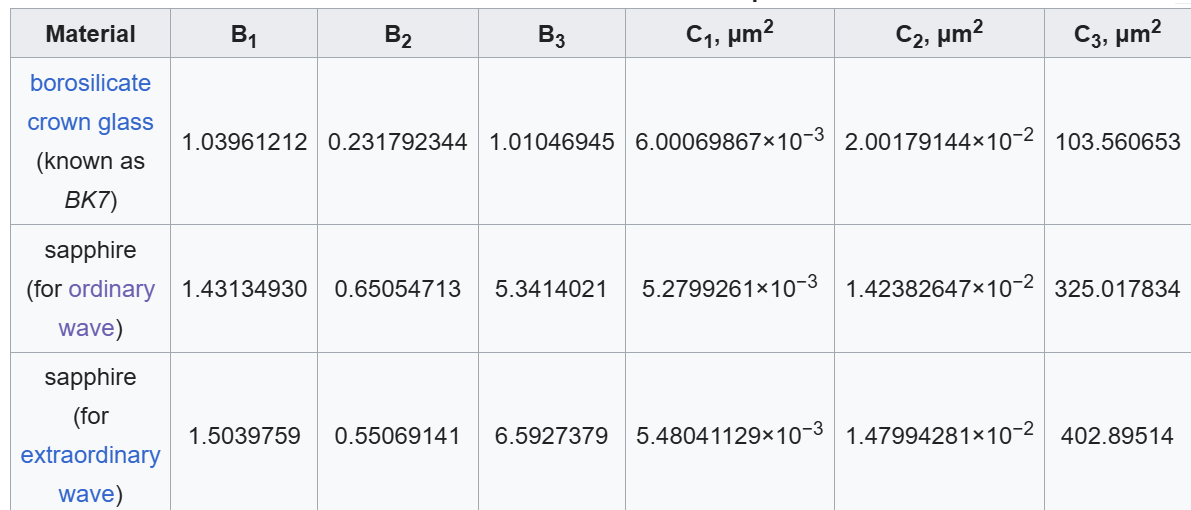

In [ ]:
#use Sympy to compute GVD of sellmeier fit and lorentz fit
lorentz_coefficients = optimized_things.x

x = sp.symbols("x", real=True, positive=True)
#initialize x as a sympy symbol

chi_lambda = oscillator_function(2*np.pi*c/x, lorentz_coefficients)
#convert x (which is in frequency) to wavelength, then plug into our fitted chi.
n_lambda = sp.sqrt(1 + chi_lambda)
GVD = (x**3/(2*np.pi*c**2))*sp.diff(n_lambda, x, 2)

# print(GVD)
print("The GVD from our Multi-Lorentzian fit at 0.8 microns (800nm) is", sp.re(GVD.evalf(subs={x: 0.8})), "s^2/micron.")
print("This is", sp.re(GVD.evalf(subs={x: 0.8}))*10**33, "fs^2/mm" )

The GVD from our Multi-Lorentzian fit at 0.8 microns (800nm) is -1.51400449588481e-32 s^2/micron.
This is -15.1400449588481 fs^2/mm


In [ ]:
# ####Doing some sanity checks with the actual n_array to see if the interpolation is behaving correctly

# #plot n vs wavelength
# plt.plot(k_array[:,0], k_array[:,1])
# plt.plot()
# plt.show()

# print(2*np.pi*c/(1e14)) #1e14 rad/s to wavelength
# print(n_lambda.evalf(subs={x:2*np.pi*c/(1e14)})) #evaluate our n_lambda function at this point
# print(np.where(k_array[:,0]>2*np.pi*c/(1e14))) #find where n_array
# print(k_array[575,1])

In [ ]:
sellmeier_coeff = np.reshape(np.array([1.431, 0.651, 5.341, 5.280e-3, 1.424e-2, 325]),(2,-1))
def sellmeier_i(x, B_i, C_i):
  return (B_i*x**2)/(x**2 - C_i)

def sellmeier_function(x, params):
  sum = 0
  for i in range(0,len(params[0,])):
    sum += sellmeier_i(x, params[0,i], params[1,i])
  return sum

sellmeier_symbolic = sp.sqrt(1 + sellmeier_function(x, sellmeier_coeff))
# print(sellmeier_symbolic)

GVD_sellmeier = (x**3/(2*np.pi*c**2))*sp.diff(sellmeier_symbolic, x, 2)

print("The GVD from the published sellmeier fit at 0.8 microns (800nm) is", GVD_sellmeier.evalf(subs={x:0.8}), "s^2/micron.")
print("This is", sp.re(GVD_sellmeier.evalf(subs={x: 0.8}))*10**33, "fs^2/mm" )

The GVD from the published sellmeier fit at 0.8 microns (800nm) is 5.87628064193661e-32 s^2/micron.
This is 58.7628064193661 fs^2/mm


Computing the GVD from the Lorentz and Sellmeier fit, we find that
$$\text{GVD}_{Lorentz}(0.8 \mu m) = -1.51 \cdot 10^{-32} \frac{s^2}{\mu m}$$
$$\text{GVD}_{Sellmeier}(0.8 \mu m) = 5.88 \cdot 10^{-32} \frac{s^2}{\mu m}$$
These two don't agree even qualitatively, being opposite signs.


---

Now, for the f-sum rule:

In [ ]:
### f-sum rule
# print(np.reshape(lorentz_coefficients, (-1, 3)))

##recall that this is in the order f_i, gamma_i, omega_i. We slice to sum over f_i
f_sum = np.sum(np.reshape(lorentz_coefficients,(-1, 3))[:,0])
print(f_sum)

6.3161534608444185324


I conjecture this is supposed to sum to $0$, but it does not.

This probably fails over a finite frequency range because we don't have all the oscillators. Also our fit isn't perfect.

---
For finding areas where our fit breaks down, let's revisit the plots from above. For variety, let's look at indices of refraction.

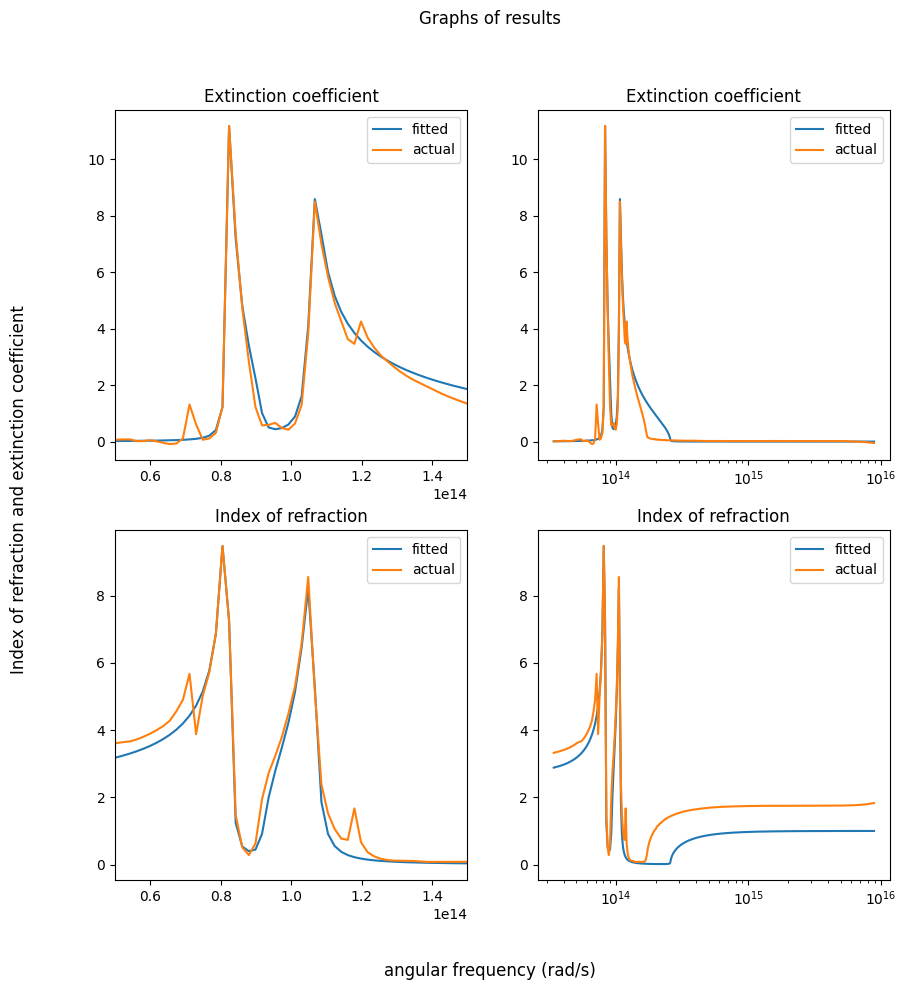

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))

fig.supxlabel("angular frequency (rad/s)")
fig.supylabel("Index of refraction and extinction coefficient")

ax[0,0].plot(omega_values, np.imag(np.sqrt(1+oscillator_function(omega_values, optimized_things.x))), label="fitted")
ax[0,0].plot(omega_values, np.imag(complex_n_omega), label="actual")
ax[0,0].set_xlim((5e13,1.5e14))
ax[0,0].set_title("Extinction coefficient")
ax[0,0].legend()

ax[1,0].plot(omega_values, np.real(np.sqrt(1+oscillator_function(omega_values,optimized_things.x))), label="fitted")
ax[1,0].plot(omega_values, np.real(complex_n_omega), label="actual")
ax[1,0].set_xlim((5e13,1.5e14))
ax[1,0].set_title("Index of refraction")
ax[1,0].legend()

ax[0,1].semilogx(omega_values, np.imag(np.sqrt(1+oscillator_function(omega_values,optimized_things.x))), label="fitted")
ax[0,1].semilogx(omega_values, np.imag(complex_n_omega), label="actual")
ax[0,1].set_title("Extinction coefficient")
ax[0,1].legend()

ax[1,1].semilogx(omega_values, np.real(np.sqrt(1+oscillator_function(omega_values,optimized_things.x))), label="fitted")
ax[1,1].semilogx(omega_values, np.real(complex_n_omega), label="actual")
# ax[1,1].axvline(x=1.7e14)
ax[1,1].set_title("Index of refraction")
ax[1,1].legend()

fig.suptitle("Graphs of results")
fig.show()

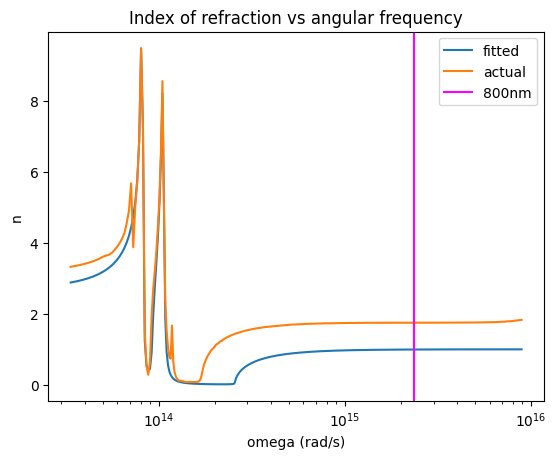

In [ ]:
plt.semilogx(omega_values, np.real(np.sqrt(1+oscillator_function(omega_values,optimized_things.x))), label="fitted")
plt.semilogx(omega_values, np.real(complex_n_omega), label="actual")
# ax[1,1].axvline(x=1.7e14)
plt.title("Index of refraction vs angular frequency")
plt.xlabel("omega (rad/s)")
plt.ylabel("n")
plt.axvline(x=2.35e15, label="800nm", color="magenta")
plt.legend()
plt.show()


In [ ]:
#find wavelengths where the peaks (and end behavior) disagree.
print(2*np.pi*c/(0.7e14))
print(2*np.pi*c/(1.2e14))
print(2*np.pi*c/(1.7e14))

26.748417450564524
15.603243512829307
11.014054244350099


Other than some disagreements on the long tails, the main frequencies of disagreement for the peaks are $0.7 \cdot 10^{14} \frac{rad}{s}$ and $1.2 \cdot 10^{14} \frac{rad}{s}$, and for the end behavior, divergince occurs around $1.7 \cdot 10^{14} \frac{rad}{s}$. Converted to wavelength, these are at $26.7 \mu m$, $15.6 \mu m$, and $11.0 \mu m$ respectively. Physical reasons might include
- nonlinear material response?
- quantum/nonclassical electron energy transitions?
- other quantum effects?

---

Extension: What model *could* we use to fit Sapphire?
First, as a sanity check, let's see if the Kramers-Kronig relations still hold.

In [ ]:
print(k_array_omega)

[[ 3.37029790e+13  1.10000000e-02]
 [ 3.55753810e+13  9.00000000e-03]
 [ 3.74477844e+13  1.80000000e-02]
 ...
 [ 8.14082270e+15 -2.60000000e-02]
 [ 8.51086010e+15 -3.90000000e-02]
 [ 8.91613915e+15 -5.20000000e-02]]


cannot select an axis to squeeze out which has size not equal to one
cannot select an axis to squeeze out which has size not equal to one


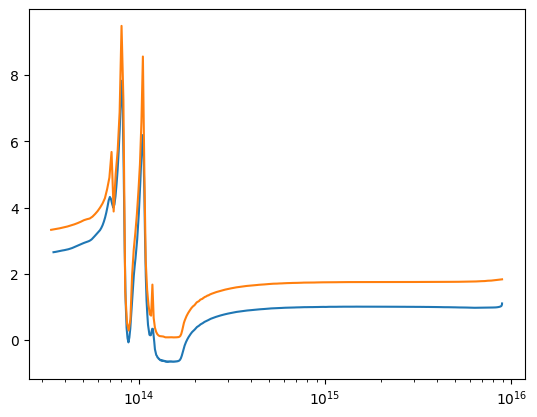

In [ ]:
x_values = np.arange(k_array_omega[0, 0], k_array_omega[-1, 0], 1e12)
interp_k = np.interp(x_values.astype(np.float64), (k_array_omega[:, 0].astype(np.float64)), (k_array_omega[:, 1].astype(np.float64)))
interp_k_array = np.concatenate((np.reshape(x_values, (-1,1)),np.reshape(interp_k,(-1,1))),axis=1)

n_omega_integrated = np.array([])

delete_x_values = np.array([])
for i in range(len(x_values)):
  try:
    omega = x_values[i]

    #mask out the x values which are within +- 3x10^13 of our pole
    left_mask = ~((x_values < omega + 1e11))
    right_mask = ~((x_values> omega - 1e11))

    #Integrate from
    x_right = x_values[right_mask]
    y_right = (interp_k[right_mask]*x_values[right_mask])/(x_values[right_mask]**2 - omega**2)

    x_left = x_values[left_mask]
    y_left = (interp_k[left_mask]*x_values[left_mask])/(x_values[left_mask]**2 - omega**2)


    n_omega_integrated = np.append(n_omega_integrated, 1+ 2/np.pi*(scipy.integrate.simpson(y_right, x_right) + scipy.integrate.simpson(y_left, x_left)))
  except Exception as e:
    print(e)
    # if we get an error, one of the masks has blocked off *all* of the x values.
    # We add that x value to a list that will later be removed.
    delete_x_values = np.append(delete_x_values,i)

#remove the flagged x values
modified_x_values = np.delete(x_values, delete_x_values.astype(int))

plt.semilogx(modified_x_values, n_omega_integrated)
plt.semilogx(n_array_omega[:,0], n_array_omega[:, 1])
plt.show()

Seems like KK seems to mostly  work. It's expected that KK should just work for all causal responses; I'm ok with calling the disagreement as being up to errors with the non-infinite bounds.

What are some ways people get this fit to work better?
- Add like 10 lorentz oscilators
- (more for spectroscopy stuff) add a quadratic background subtraction?
- I could try to set bounds on the oscillators and try to get them to fit in particular frequencies
- Frequency-dependent damping https://doi.org/10.1016/S0030-4018(98)00503-3.
- Arunava's idea: Fit the data piecewise with (Lorentz + c) and then combine them all together?
- Some advanced stuff with "phonon modes"?

However, I'm inclined to think the model just breaks down.
See: Reststrahlen model? https://pubs.rsc.org/en/content/articlepdf/2026/ra/d5ra06643c (apparently the lorentz model is only good for near the resonance modes of the phonons).